<a href="https://colab.research.google.com/github/DanKzDev/API/blob/main/Frutos_Rojos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [144]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

img = cv2.imread(list(uploaded.keys())[0])

if img is None:
    print("Error. No se encontró imagen")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title("Imagen original")
    plt.axis("off")


TypeError: 'NoneType' object is not subscriptable

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

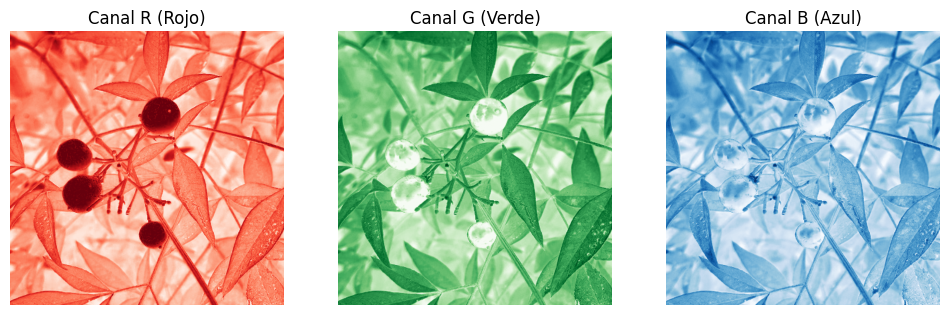

In [ ]:
R = img_rgb[:,:,0]
G = img_rgb[:,:,1]
B = img_rgb[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Canal R (Rojo)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Canal G (Verde)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Canal B (Azul)")
plt.axis("off")



(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

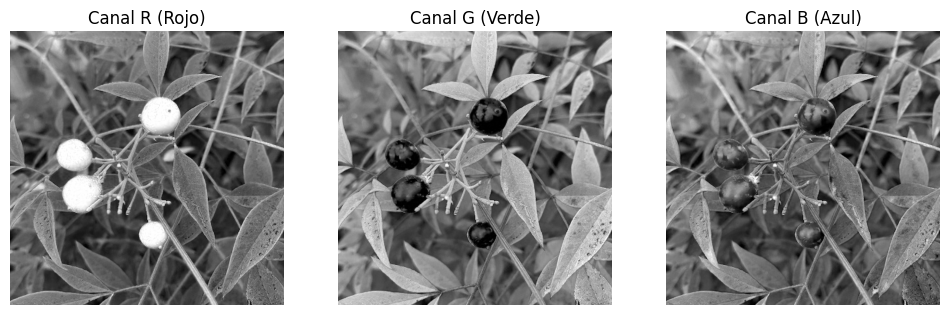

In [ ]:
R = img_rgb[:,:,0]
G = img_rgb[:,:,1]
B = img_rgb[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='gray')
plt.title("Canal R (Rojo)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='gray')
plt.title("Canal G (Verde)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='gray')
plt.title("Canal B (Azul)")
plt.axis("off")


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

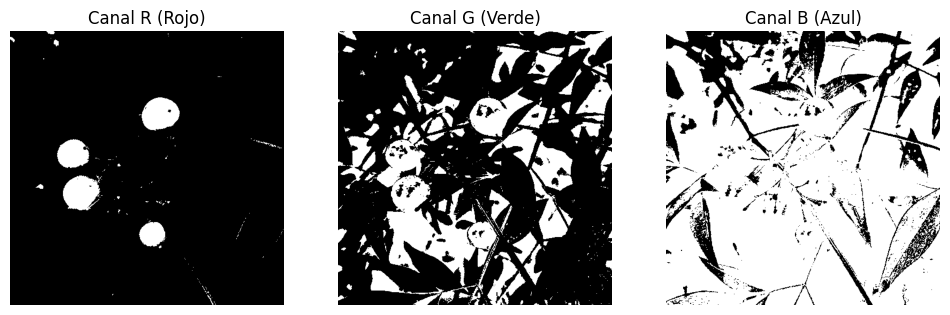

In [ ]:

maskR = (R>215).astype(np.uint8) * 255
maskG = (G<90).astype(np.uint8) * 255
maskB = (B<150).astype(np.uint8) * 255

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(maskR, cmap='gray')
plt.title("Canal R (Rojo)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(maskG, cmap='gray')
plt.title("Canal G (Verde)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(maskB, cmap='gray')
plt.title("Canal B (Azul)")
plt.axis("off")

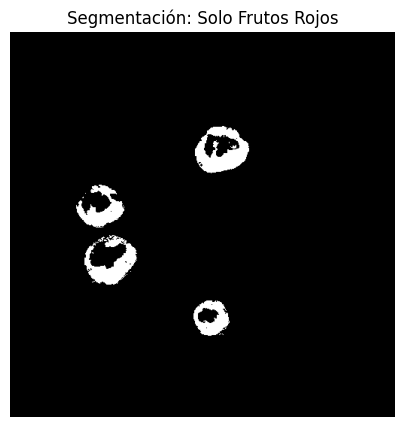

In [ ]:
umbral_rojo = 200
umbral_otros = 100

mask_frutos = (R > umbral_rojo) & (G < umbral_otros) & (B < umbral_otros)

mask_frutos = mask_frutos.astype(np.uint8) * 255

plt.figure(figsize=(5, 5))
plt.imshow(mask_frutos, cmap='gray')
plt.title("Segmentación: Solo Frutos Rojos")
plt.axis("off")
plt.show()


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

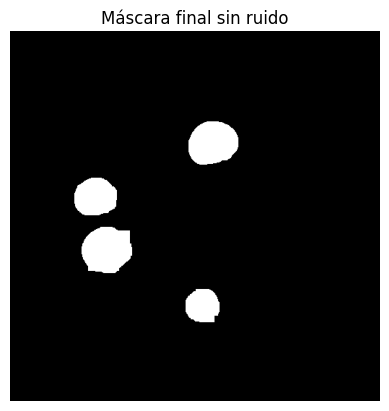

In [ ]:


kernel = np.ones((11,11), np.uint8)

mask_clean = cv2.morphologyEx(maskR, cv2.MORPH_CLOSE, kernel)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel)

contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

mask_no_noise = np.zeros_like(mask_clean)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 500:
        cv2.drawContours(mask_no_noise, [cnt], -1, 255, -1)

plt.imshow(mask_no_noise, cmap='gray')
plt.title("Máscara final sin ruido | Relleno")
plt.axis("off")


In [ ]:
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print("Cantidad de frutos detectados:", len(contours))

Cantidad de frutos detectados: 4


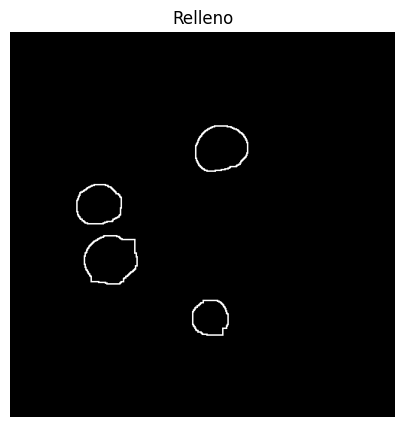

In [ ]:
kernel_borde = np.ones((3,3), np.uint8)
mask_edges = cv2.morphologyEx(mask_no_noise, cv2.MORPH_GRADIENT, kernel_borde)

plt.figure(figsize=(5,5))
plt.imshow(mask_edges, cmap='gray')
plt.title("Relleno")
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

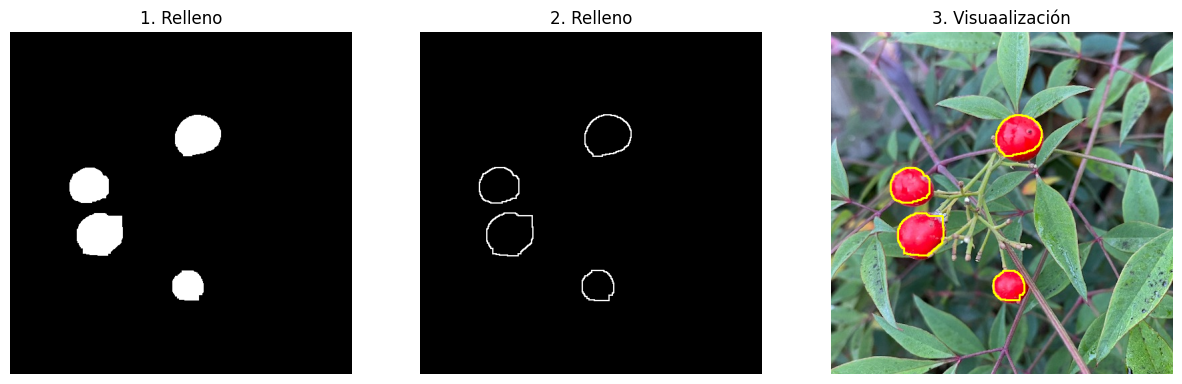

In [145]:
img_contornos_amarillo = img_rgb.copy()
amarillo = (255, 255, 0)

cv2.drawContours(img_contornos_amarillo, contours, -1, amarillo, 2)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask_no_noise, cmap='gray')
plt.title("1. Relleno")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_edges, cmap='gray')
plt.title("2. Relleno")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_contornos_amarillo)
plt.title("3. Visuaalización")
plt.axis("off")